In [1]:
import torch

# For constructing DataLoder
from torchvision import transforms
from torchvision import datasets
from torch.utils.data import DataLoader

# For using function relu()
import torch.nn.functional as F

# For constructing Optimizer
import torch.optim as optim


import matplotlib.pyplot as plt

In [2]:
# Prepare dataset
batch_size = 64
transform = transforms.Compose([transforms.ToTensor(), transforms.Normalize((0.1307,), (0.3081,))])
 
train_dataset = datasets.MNIST(root='mnist/', train=True, download=True, transform=transform)
train_loader = DataLoader(train_dataset, shuffle=True, batch_size=batch_size)

test_dataset = datasets.MNIST(root='mnist/', train=False, download=True, transform=transform)
test_loader = DataLoader(test_dataset, shuffle=False, batch_size=batch_size)

In [3]:
# Define model
class Net(torch.nn.Module):
    def __init__(self):
        super(Net, self).__init__()
        self.conv1 = torch.nn.Conv2d(1, 10, kernel_size=5)
        self.conv2 = torch.nn.Conv2d(10, 20, kernel_size=5)
        self.pooling = torch.nn.MaxPool2d(2)
        self.fc = torch.nn.Linear(320, 10)
        
    def forward(self, x):
        # flatten data from (n,1,28,28) to (n,784)
        batch_size = x.size(0)
        x = F.relu(self.pooling(self.conv1(x)))
        x = F.relu(self.pooling(self.conv2(x)))
        x = x.view(batch_size, -1)
        x = self.fc(x)
        
        return x
    
model = Net()

In [4]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)

Net(
  (conv1): Conv2d(1, 10, kernel_size=(5, 5), stride=(1, 1))
  (conv2): Conv2d(10, 20, kernel_size=(5, 5), stride=(1, 1))
  (pooling): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (fc): Linear(in_features=320, out_features=10, bias=True)
)

In [5]:
# Construct Loss and Optimizer
criterion = torch.nn.CrossEntropyLoss()
optimizer = optim.SGD(model.parameters(), lr=0.01, momentum=0.5)

In [6]:
# Train and Test
def train(epoch):
    running_loss = 0.0
    for batch_idx, data in enumerate(train_loader, 0):
        inputs, target = data
        inputs, target = inputs.to(device), target.to(device)
        optimizer.zero_grad()
        
        # forward + backward + update
        outputs = model(inputs)
        loss = criterion(outputs, target)
        loss.backward()
        optimizer.step()
 
        running_loss += loss.item()
        if batch_idx % 300 == 299:
            print('[%d, %5d] loss: %.3f' % (epoch + 1, batch_idx + 1, running_loss / 300))
            running_loss = 0.0
            
def test():
    correct = 0
    total = 0
    with torch.no_grad():
        for data in test_loader:
            images, labels = data
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            _, predicted = torch.max(outputs.data, dim=1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
    print('Accuracy on test set: %d %% ' % (100 * correct / total))
    return correct / total

In [7]:
if __name__ == '__main__':
    epoch_list = []
    acc_list = []
    for epoch in range(10):
        train(epoch)
        acc = test()
        epoch_list.append(epoch)
        acc_list.append(acc)

[1,   300] loss: 0.593
[1,   600] loss: 0.181
[1,   900] loss: 0.126
Accuracy on test set: 96 % 
[2,   300] loss: 0.109
[2,   600] loss: 0.092
[2,   900] loss: 0.081
Accuracy on test set: 97 % 
[3,   300] loss: 0.075
[3,   600] loss: 0.072
[3,   900] loss: 0.063
Accuracy on test set: 98 % 
[4,   300] loss: 0.063
[4,   600] loss: 0.056
[4,   900] loss: 0.059
Accuracy on test set: 98 % 
[5,   300] loss: 0.055
[5,   600] loss: 0.052
[5,   900] loss: 0.053
Accuracy on test set: 98 % 
[6,   300] loss: 0.048
[6,   600] loss: 0.049
[6,   900] loss: 0.045
Accuracy on test set: 98 % 
[7,   300] loss: 0.043
[7,   600] loss: 0.043
[7,   900] loss: 0.044
Accuracy on test set: 98 % 
[8,   300] loss: 0.037
[8,   600] loss: 0.041
[8,   900] loss: 0.043
Accuracy on test set: 98 % 
[9,   300] loss: 0.039
[9,   600] loss: 0.036
[9,   900] loss: 0.038
Accuracy on test set: 98 % 
[10,   300] loss: 0.034
[10,   600] loss: 0.037
[10,   900] loss: 0.035
Accuracy on test set: 98 % 


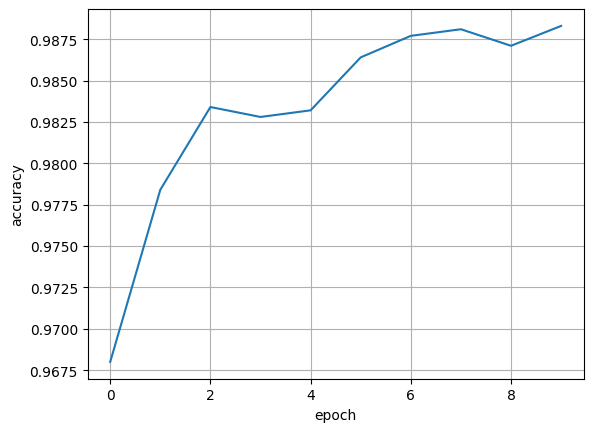

In [9]:
plt.plot(epoch_list, acc_list)
plt.ylabel('accuracy')
plt.xlabel('epoch')
plt.grid(True)
plt.show()